# Marketing Performance Report
## Channel & Campaign Analysis

Prepare by: Arfan Kafait
Date: 02/22/2026

## Objective

Analyze marketing campaign performance to:

- Identify the most profitable channel
- Compare campaign ROI
- Evaluate cost efficiency (CPA)
- Recommend budget allocation

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
df = pd.read_csv(r"D:\Python Learning\New folder\marketing_data.csv")

In [34]:
df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         8 non-null      object
 1   channel      8 non-null      object
 2   campaign     8 non-null      object
 3   cost         8 non-null      int64 
 4   conversions  8 non-null      int64 
 5   revenue      8 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 512.0+ bytes


In [35]:
df.columns = df.columns.str.strip().str.lower()
df.isnull().sum()

date           0
channel        0
campaign       0
cost           0
conversions    0
revenue        0
dtype: int64

No missing values detected. Data types are appropriate for analysis.

In [36]:
df["profit"] = df["revenue"] - df["cost"]
df["roi"] = df["profit"] / df["cost"]
df["cpa"]  = df["cost"] / df["conversions"]

df.head()

,date,channel,campaign,cost,conversions,revenue,profit,roi,cpa
0,1/1/2024,Google,Search_A,120,6,300,180,1.500000,20.000000
1,1/1/2024,Facebook,FB_Lead_1,150,3,180,30,0.200000,50.000000
2,1/2/2024,Google,Search_A,100,5,250,150,1.500000,20.000000
3,1/2/2024,Facebook,FB_Lead_1,160,2,120,-40,-0.250000,80.000000
4,1/3/2024,Google,Search_B,130,7,350,220,1.692308,18.571429


New metrics created:
- Profit
- ROI
- CPA

In [37]:
channel_summary = df.groupby("channel").agg(
    total_revenue=("revenue", "sum"),
    total_cost=("cost", "sum"),
    total_profit = ("profit", "sum"),
    avg_roi = ("roi", "mean"),
    avg_cpa = ("cpa", "mean"),
)
channel_summary

,total_revenue,total_cost,total_profit,avg_roi,avg_cpa
channel,,,,,
Facebook,685,605,80,0.146486,54.166667
Google,1200,460,740,1.604895,19.226190


In [38]:
df.groupby("campaign")["roi"].mean().sort_values(ascending=False)

campaign
Search_B     1.709790
Search_A     1.500000
FB_Lead_2    0.317972
FB_Lead_1   -0.025000
Name: roi, dtype: float64

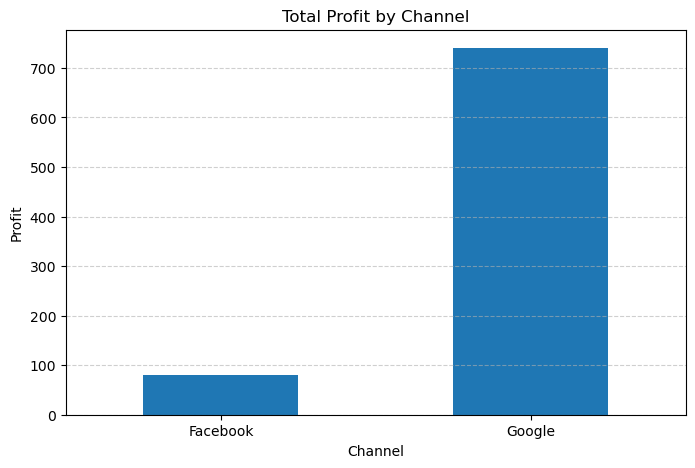

In [39]:
plt.figure(figsize=(8, 5))
channel_summary["total_profit"].plot(kind="bar")
plt.title("Total Profit by Channel")
plt.xlabel("Channel")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [40]:
campaign_summary = df.groupby("campaign").agg(
    total_profit=("profit", "sum"),
    avg_roi=("roi", "mean"),
).sort_values("avg_roi", ascending=False)

campaign_summary

,total_profit,avg_roi
campaign,,
Search_B,410,1.709790
Search_A,330,1.500000
FB_Lead_2,90,0.317972
FB_Lead_1,-10,-0.025000


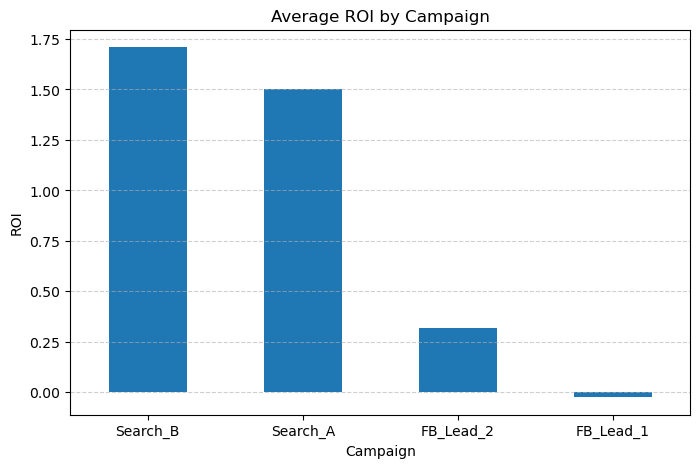

In [41]:
plt.figure(figsize=(8, 5))
campaign_summary["avg_roi"].plot(kind="bar")
plt.title("Average ROI by Campaign")
plt.xlabel("Campaign")
plt.ylabel("ROI")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


## Key Insights

- Google generated significantly higher total profit than Facebook.
- Search_B delivered the highest ROI and shows strong scalability.
- FB_Lead_1 operates at weak performance and may require optimization.
- Google has lower CPA, indicating better cost efficiency.

## Recommendation

Allocate higher budget to Search_B and Search_A.
Reduce or optimize underperforming Facebook campaign.

In [42]:
channel_summary.to_excel("channel_summary.xlsx")
campaign_summary.to_excel("campaign_summary.xlsx")

In [43]:
plt.savefig("roi_chart.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>